# Module 08 — Differential Expression Analysis (v5)

This notebook visualizes pre-computed pseudobulk differential expression results
from `scripts/08_differential.py`. Pseudobulk aggregation (summing counts per
donor per cell type) avoids treating cells as independent observations, and
pyDESeq2 is used for statistical testing.

**Pipeline version:** v5 (CCA-based, 12 modules)

**Data sources:**
- `results/differential/de_summary_table.tsv` — Summary of all comparisons
- `results/differential/skipped_comparisons.tsv` — Underpowered comparisons
- `results/differential/de_results_combined.tsv` — Full DE results
- `results/differential/volcano_plots/` — Volcano plots per comparison
- `results/differential/heatmaps/` — Heatmaps of top DE genes
- `results/differential/composition_analysis.tsv` — Cell type composition changes

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
RESULTS = BASE / 'results' / 'differential'
VOLCANO_DIR = RESULTS / 'volcano_plots'
HEATMAP_DIR = RESULTS / 'heatmaps'

print(f'Results directory: {RESULTS}')
print(f'Volcano plots:    {len(list(VOLCANO_DIR.glob("*.png")))} files')
print(f'Heatmaps:         {len(list(HEATMAP_DIR.glob("*.png")))} files')

Results directory: /home/ubuntu/lotz-ivd/results/differential
Volcano plots:    10 files
Heatmaps:         1 files


## DE Summary Table

Each row represents one powered comparison (cell type x condition pair). The
table shows the number of significantly up- and down-regulated genes per
comparison.

In [2]:
summary = pd.read_csv(RESULTS / 'de_summary_table.tsv', sep='\t')
print(f'Total powered comparisons: {len(summary)}')
print(f'Total significant genes (sum across comparisons): {summary["n_total"].sum()}')

display(summary.style.set_caption('Pseudobulk DE Summary — All Powered Comparisons'))

Total powered comparisons: 10
Total significant genes (sum across comparisons): 1198


,cell_type,comparison,n_up,n_down,n_total
0,AF_inner,healthy_vs_degenerated_severe,3,2,5
1,AF_outer,healthy_vs_degenerated_all,0,1,1
2,AF_outer,healthy_vs_degenerated_mild,4,114,118
3,AF_outer,healthy_vs_degenerated_severe,15,4,19
4,AF_outer,mild_vs_severe,3,1,4
5,NP_fibrocartilaginous,healthy_vs_degenerated_all,20,8,28
6,NP_fibrocartilaginous,healthy_vs_degenerated_mild,7,7,14
7,NP_fibrocartilaginous,healthy_vs_degenerated_severe,237,319,556
8,NP_fibrocartilaginous,mild_vs_severe,138,263,401
9,NP_mature_chondrocyte,mild_vs_severe,33,19,52


In [3]:
# Unique significant genes across all comparisons
de_combined = pd.read_csv(RESULTS / 'de_results_combined.tsv', sep='\t')

# Detect column name for log2 fold change
lfc_col = next((c for c in ['log2FC', 'log2FoldChange'] if c in de_combined.columns), 'log2FC')

sig = de_combined[(de_combined['padj'] < 0.05) & (de_combined[lfc_col].abs() > 0.5)]
print(f'Unique significant genes: {sig["gene"].nunique()}')
print(f'Total significant hits:   {len(sig)}')
print(f'\nCell types with DE results: {sig["cell_type"].nunique()}')
for ct in sorted(sig['cell_type'].unique()):
    n = sig[sig['cell_type'] == ct]['gene'].nunique()
    print(f'  {ct}: {n} genes')

# Top upregulated genes
print()
top_up = sig.nlargest(15, lfc_col)
cols = [c for c in ['gene', lfc_col, 'padj', 'cell_type', 'comparison'] if c in top_up.columns]
display(top_up[cols].style.set_caption('Top 15 Upregulated DE Genes (by log2FC)'))

# Top downregulated genes
top_down = sig.nsmallest(15, lfc_col)
display(top_down[cols].style.set_caption('Top 15 Downregulated DE Genes (by log2FC)'))

Unique significant genes: 979
Total significant hits:   1198

Cell types with DE results: 4
  AF_inner: 5 genes
  AF_outer: 139 genes
  NP_fibrocartilaginous: 797 genes
  NP_mature_chondrocyte: 52 genes



,gene,log2FC,padj,cell_type,comparison
145103,SFRP2,6.630740,0.003579,NP_fibrocartilaginous,healthy_vs_degenerated_severe
47227,PLA2G2A,5.053978,0.007834,NP_fibrocartilaginous,healthy_vs_degenerated_all
149676,EYA2,5.039574,0.007403,NP_fibrocartilaginous,healthy_vs_degenerated_severe
142717,PLA2G2A,5.024151,0.006646,NP_fibrocartilaginous,healthy_vs_degenerated_severe
133882,CEMIP,4.591755,0.000000,NP_fibrocartilaginous,healthy_vs_degenerated_severe
200093,MFAP5,4.378982,0.016421,NP_fibrocartilaginous,mild_vs_severe
39398,CYTL1,4.375250,0.001653,NP_fibrocartilaginous,healthy_vs_degenerated_all
137934,HOXD10,4.353311,0.026303,NP_fibrocartilaginous,healthy_vs_degenerated_severe
137508,HAGLR,4.290197,0.005497,NP_fibrocartilaginous,healthy_vs_degenerated_severe
145104,SFRP4,4.226444,0.014435,NP_fibrocartilaginous,healthy_vs_degenerated_severe


,gene,log2FC,padj,cell_type,comparison
54141,DNTT,-43.280851,0.000830,NP_fibrocartilaginous,healthy_vs_degenerated_all
337593,C2orf40,-20.923420,0.000111,AF_outer,healthy_vs_degenerated_mild
149732,HBM,-19.551301,0.013862,NP_fibrocartilaginous,healthy_vs_degenerated_severe
209285,HBM,-18.352759,0.000000,NP_fibrocartilaginous,mild_vs_severe
133316,CAMP,-17.550071,0.008036,NP_fibrocartilaginous,healthy_vs_degenerated_severe
133218,CA1,-16.898596,0.013401,NP_fibrocartilaginous,healthy_vs_degenerated_severe
345658,MT-RNR1,-16.747862,0.000589,AF_outer,healthy_vs_degenerated_mild
344669,LRRC75A-AS1,-15.230980,0.003202,AF_outer,healthy_vs_degenerated_mild
337668,C6orf48,-14.286038,0.007585,AF_outer,healthy_vs_degenerated_mild
341962,GPX1,-14.186570,0.007585,AF_outer,healthy_vs_degenerated_mild


## Skipped (Underpowered) Comparisons

Comparisons that did not meet the minimum donor threshold (>= 3 donors per
group) are listed here with the reason for exclusion.

In [4]:
skipped = pd.read_csv(RESULTS / 'skipped_comparisons.tsv', sep='\t')
print(f'Skipped comparisons: {len(skipped)}')
display(skipped)

Skipped comparisons: 47


,comparison,reason
0,Endothelial | healthy_vs_degenerated_all,"Underpowered: 2 ref, 8 test (need >= 3)"
1,T_cell_CD8 | healthy_vs_degenerated_all,"Underpowered: 2 ref, 4 test (need >= 3)"
2,Macrophage_M2 | healthy_vs_degenerated_all,No valid samples with >= 50 cells
3,Endothelial | healthy_vs_degenerated_mild,"Underpowered: 2 ref, 3 test (need >= 3)"
4,T_cell_CD8 | healthy_vs_degenerated_mild,"Underpowered: 2 ref, 2 test (need >= 3)"
5,Macrophage_M2 | healthy_vs_degenerated_mild,No valid samples with >= 50 cells
6,NP_mature_chondrocyte | healthy_vs_degenerated...,DESeq2 error: Singular matrix
7,Endothelial | healthy_vs_degenerated_severe,"Underpowered: 2 ref, 5 test (need >= 3)"
8,T_cell_CD8 | healthy_vs_degenerated_severe,"Underpowered: 2 ref, 2 test (need >= 3)"
9,Macrophage_M2 | healthy_vs_degenerated_severe,No valid samples with >= 50 cells


## Volcano Plots

Volcano plots show the relationship between fold change (x-axis) and
statistical significance (y-axis) for each comparison. Points colored by
significance threshold (|log2FC| > 0.5, padj < 0.05).

### Key resident cell type comparisons

**NP fibrocartilaginous healthy vs degenerated all**

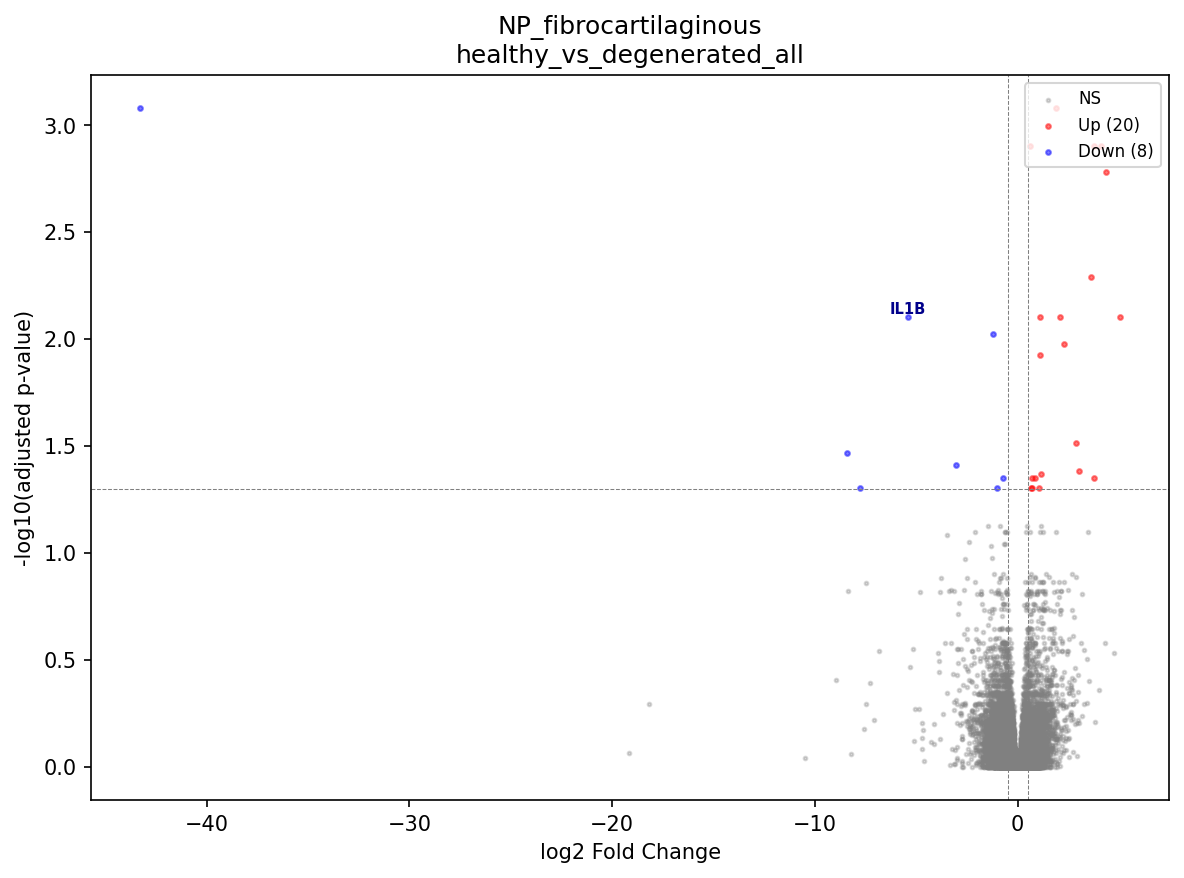

**NP fibrocartilaginous healthy vs degenerated mild**

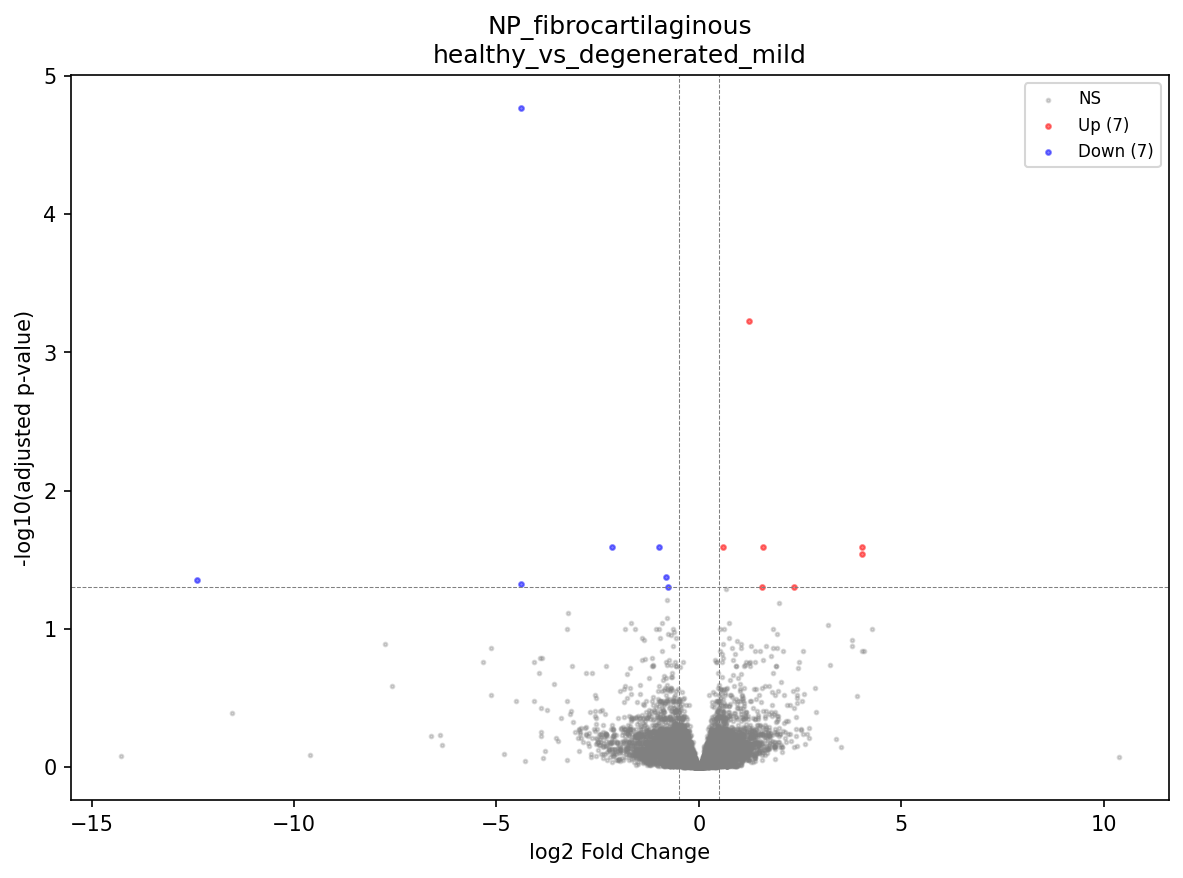

**NP fibrocartilaginous healthy vs degenerated severe**

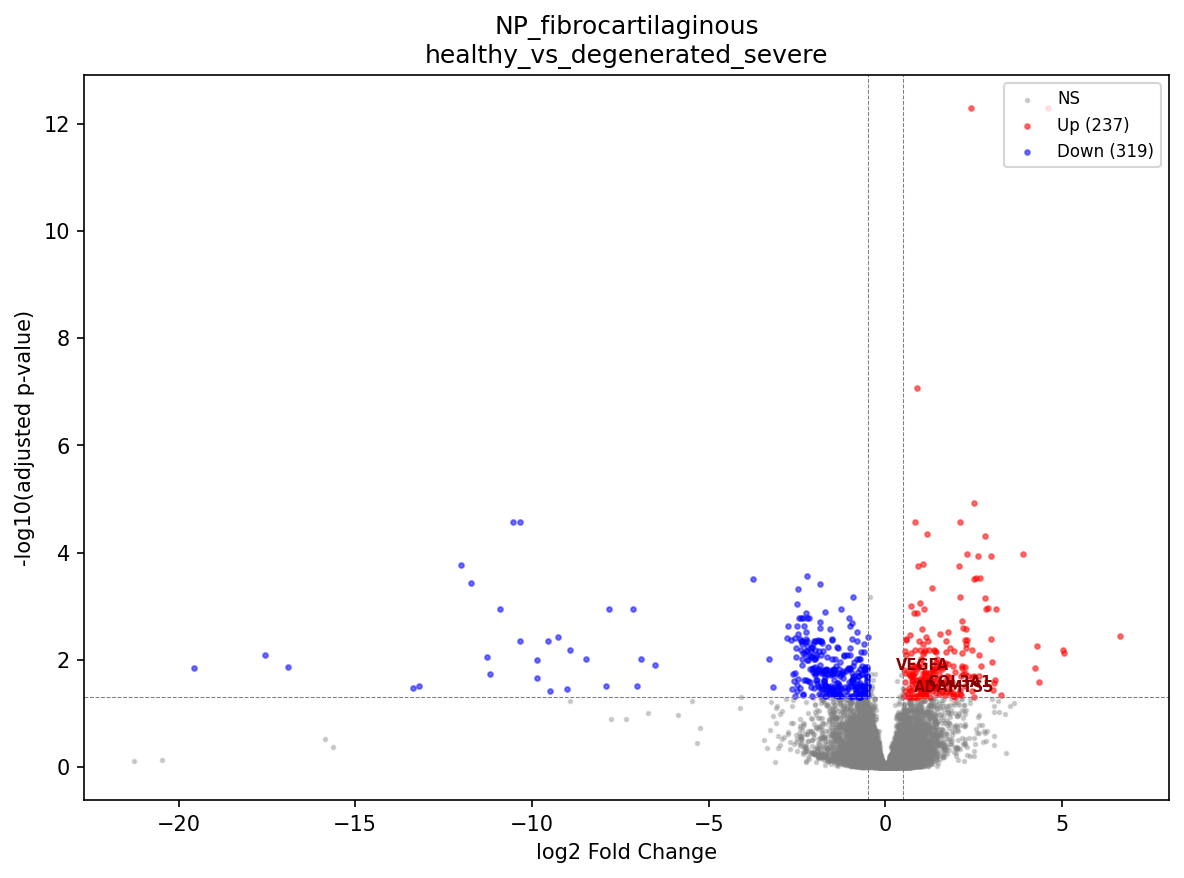

**AF outer healthy vs degenerated all**

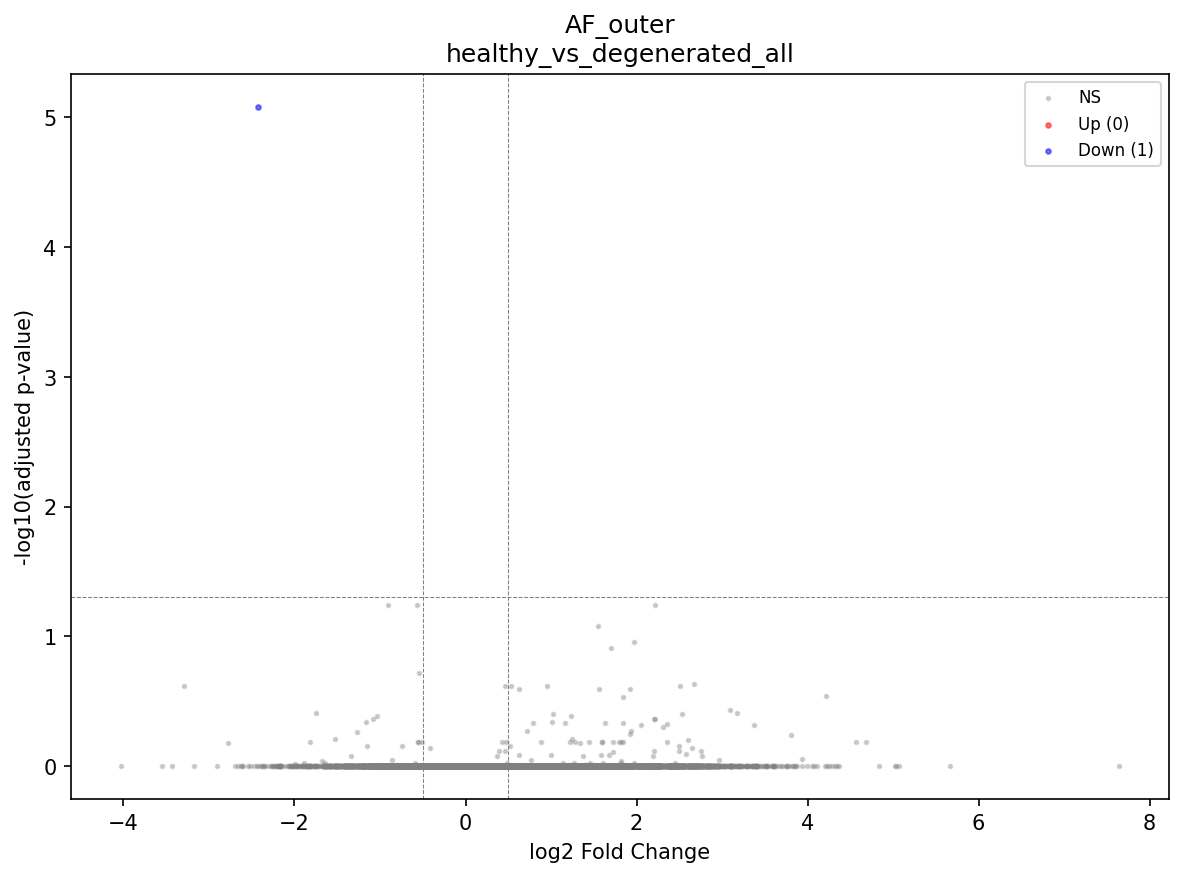

**AF outer healthy vs degenerated mild**

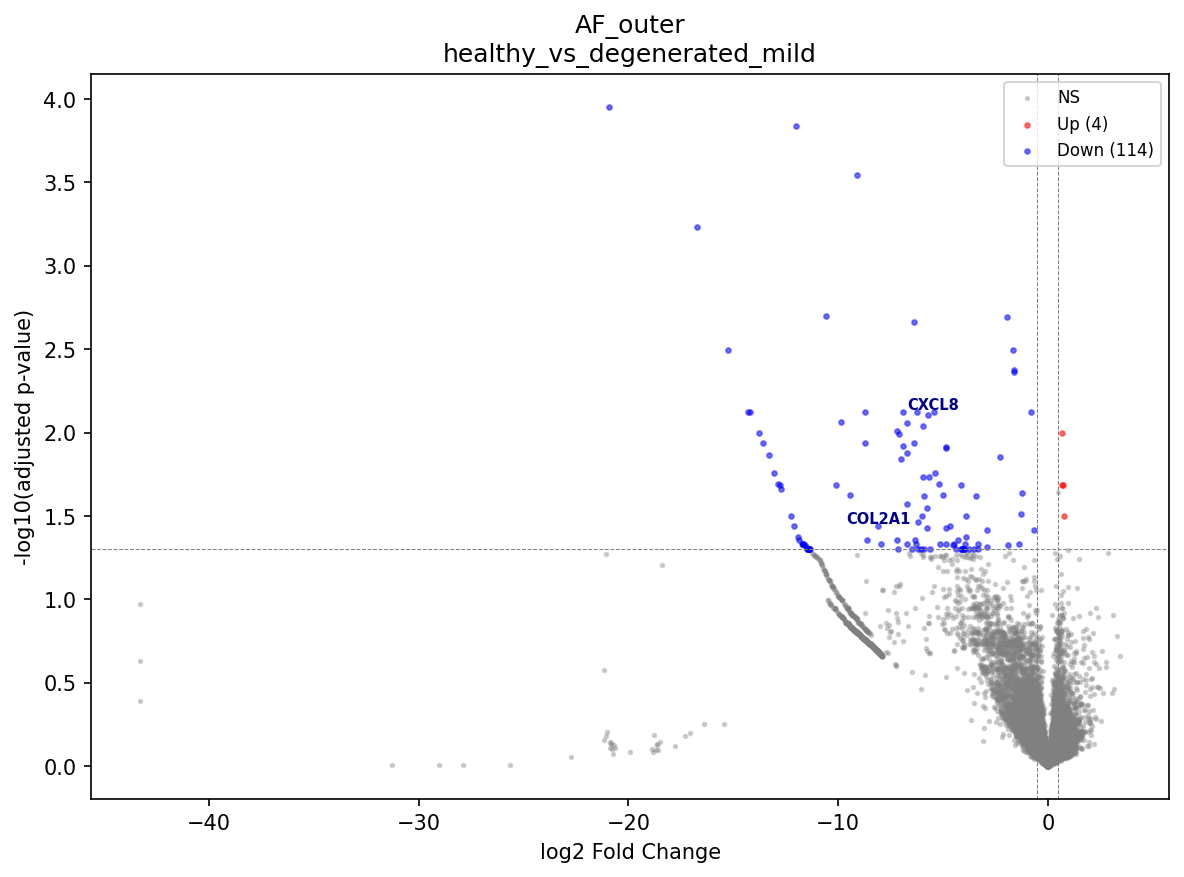

**AF outer healthy vs degenerated severe**

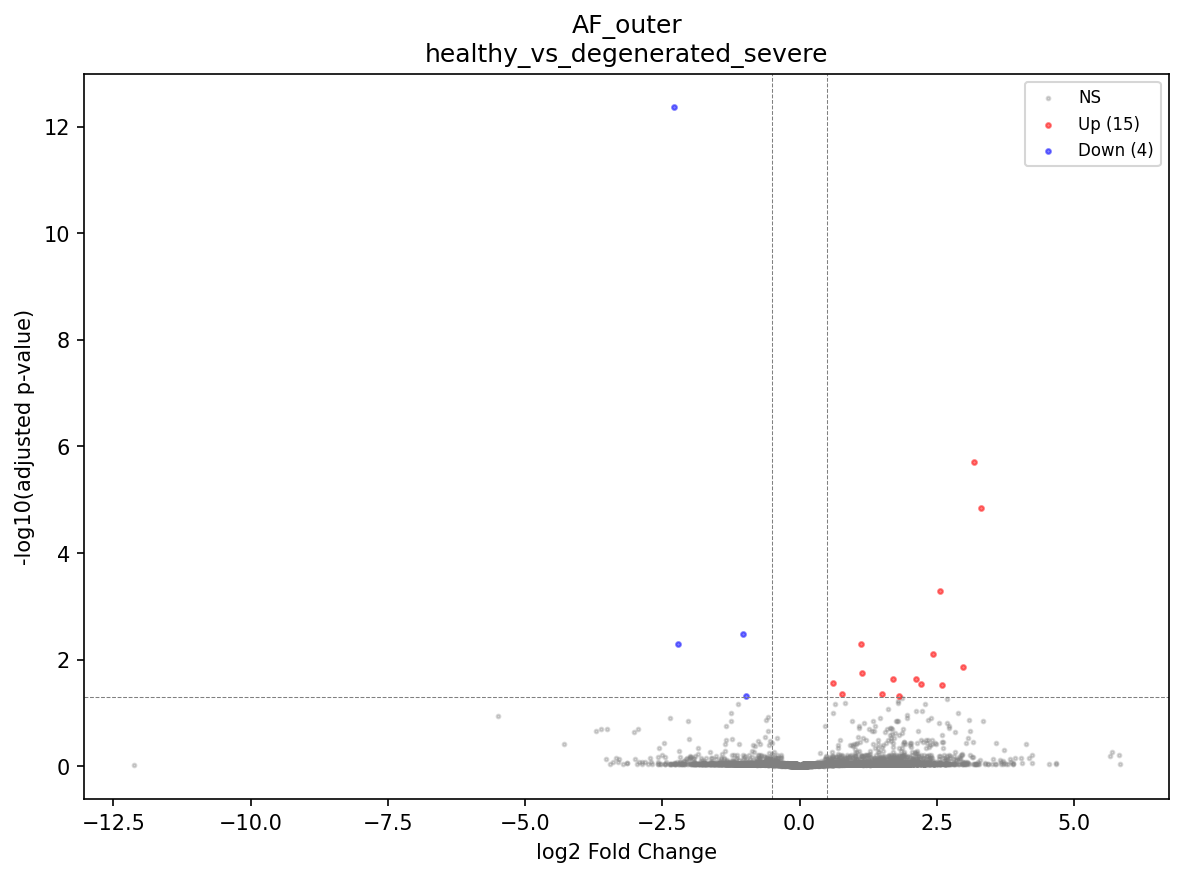

**AF inner healthy vs degenerated severe**

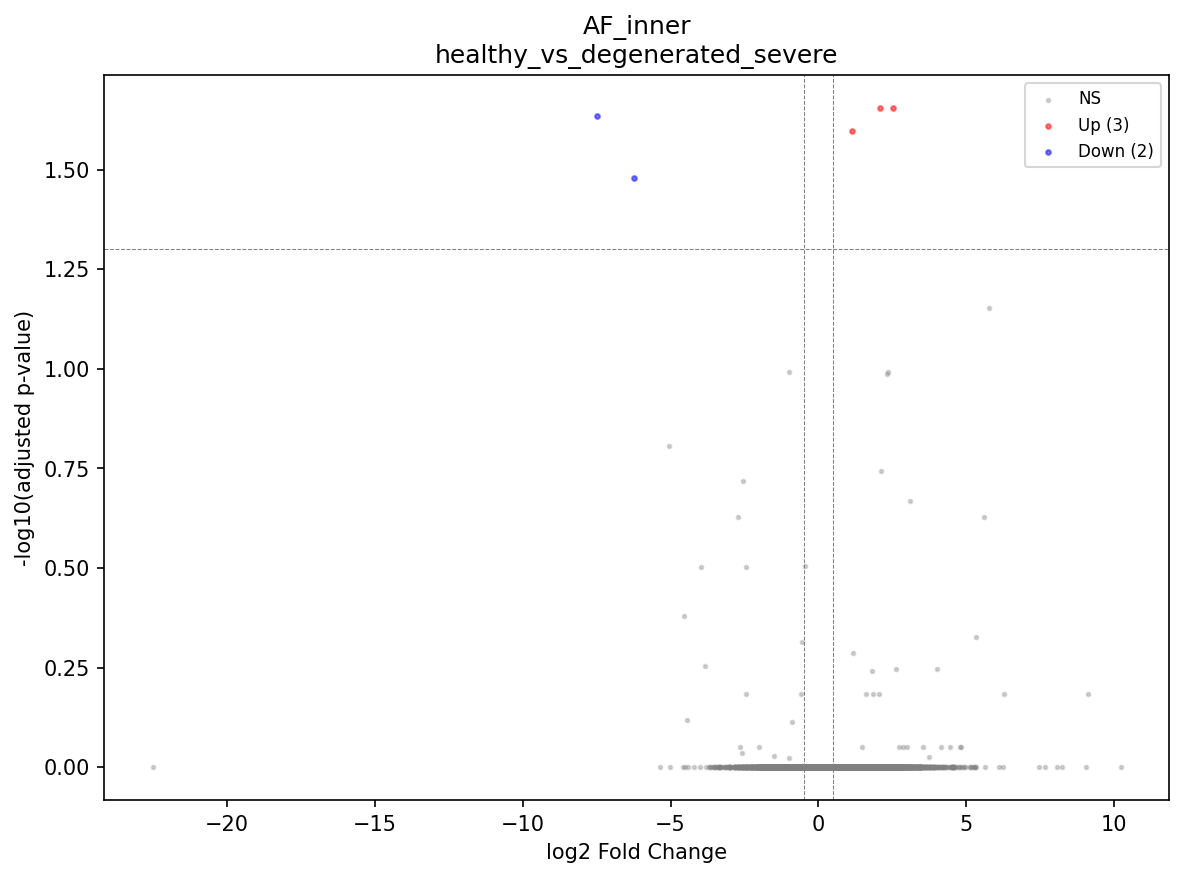

In [5]:
# Display key volcano plots for resident cell types
# Dynamically find available volcano plots rather than hardcoding filenames
key_patterns = [
    'NP_mature_chondrocyte_healthy',
    'NP_fibrocartilaginous_healthy',
    'AF_outer_healthy',
    'AF_inner_healthy',
    'EP_hyaline_healthy',
    'NP_notochordal_healthy',
]

for pattern in key_patterns:
    matches = sorted(VOLCANO_DIR.glob(f'volcano_{pattern}*.png'))
    for fpath in matches:
        label = fpath.stem.replace('volcano_', '').replace('_', ' ')
        display(Markdown(f'**{label}**'))
        display(Image(filename=str(fpath), width=700))

# Show any healthy-vs comparisons not covered above
shown = set()
for pattern in key_patterns:
    shown.update(f.name for f in VOLCANO_DIR.glob(f'volcano_{pattern}*.png'))
remaining_healthy = sorted(f for f in VOLCANO_DIR.glob('*healthy*.png') if f.name not in shown)
for fpath in remaining_healthy:
    label = fpath.stem.replace('volcano_', '').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=700))

### Severity-stratified comparisons (mild vs severe)

**AF outer mild vs severe**

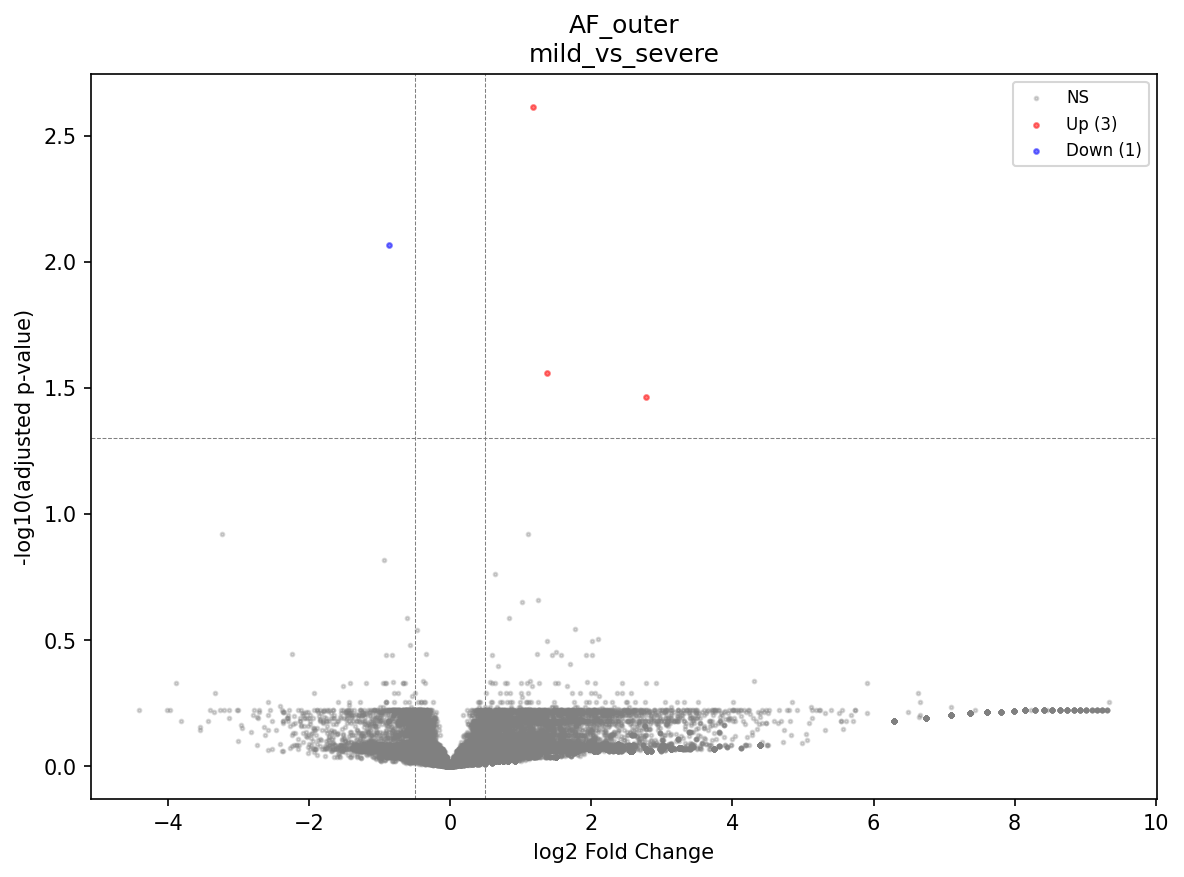

**NP fibrocartilaginous mild vs severe**

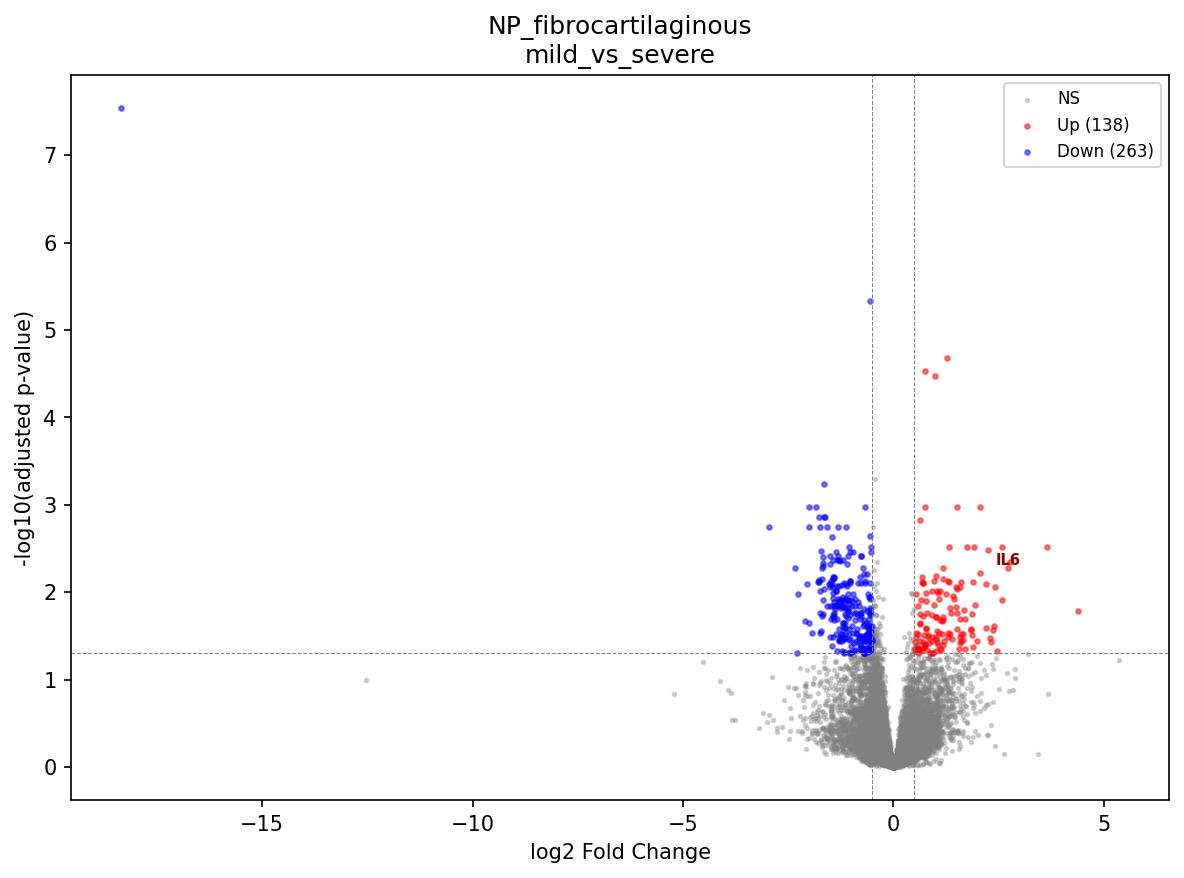

**NP mature chondrocyte mild vs severe**

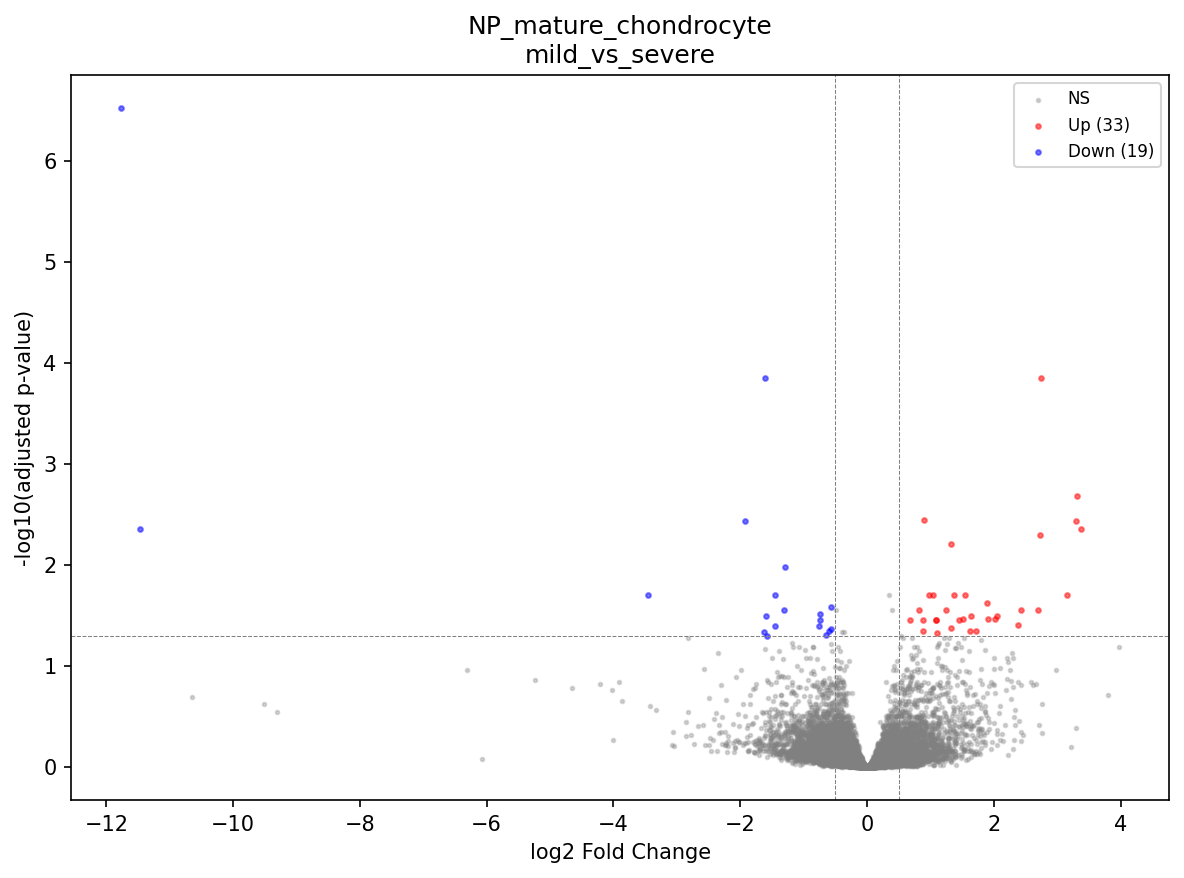

In [6]:
# Display mild vs severe comparisons
severity_volcanos = sorted(VOLCANO_DIR.glob('*mild_vs_severe*.png'))

for fpath in severity_volcanos:
    label = fpath.stem.replace('volcano_', '').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=700))

### All remaining volcano plots

In [7]:
# Show any remaining volcano plots not already displayed
already_shown_patterns = [
    'NP_mature_chondrocyte_healthy',
    'NP_fibrocartilaginous_healthy',
    'AF_outer_healthy',
    'AF_inner_healthy',
    'EP_hyaline_healthy',
    'NP_notochordal_healthy',
]
already_shown = set()
for pattern in already_shown_patterns:
    already_shown.update(f.name for f in VOLCANO_DIR.glob(f'volcano_{pattern}*.png'))
already_shown.update(f.name for f in VOLCANO_DIR.glob('*mild_vs_severe*.png'))

remaining = sorted(f for f in VOLCANO_DIR.glob('*.png') if f.name not in already_shown)

print(f'Remaining volcano plots: {len(remaining)}')
for fpath in remaining:
    label = fpath.stem.replace('volcano_', '').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=700))

Remaining volcano plots: 0


## Heatmaps — Top DE Genes

Heatmaps show expression of the top differentially expressed genes across
pseudobulk samples (donors), organized by condition. These complement the
volcano plots by showing the consistency of expression changes across donors.

Heatmap files: 1


**NP fibrocartilaginous healthy vs deg**

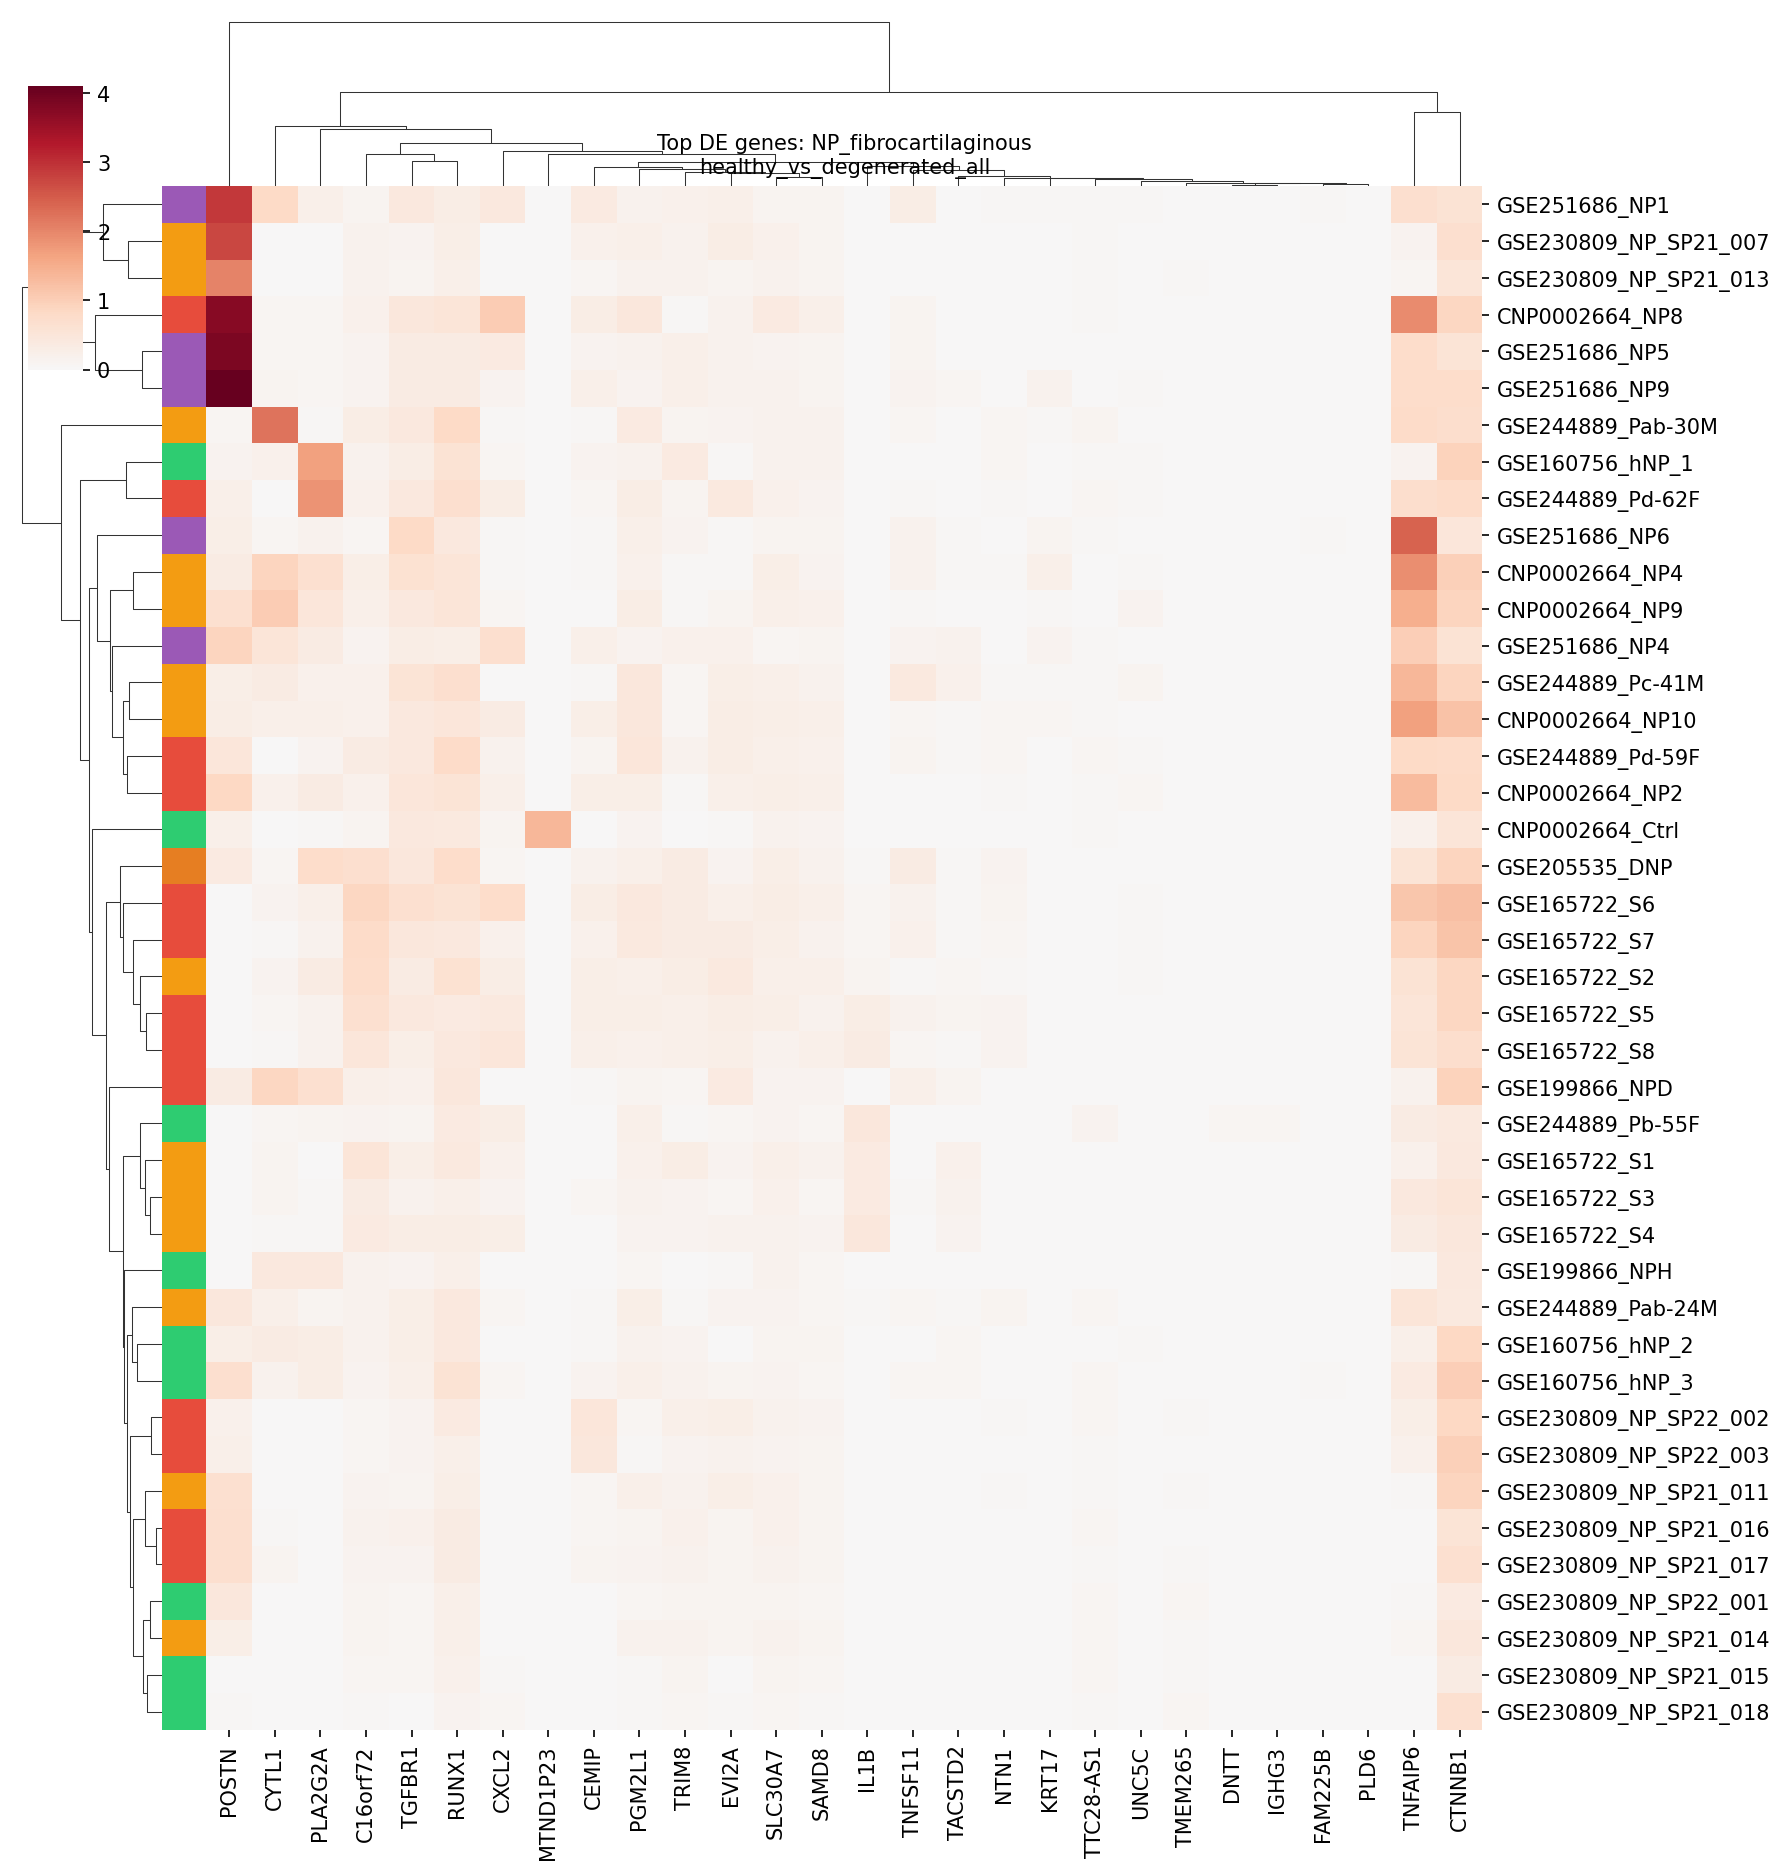

In [8]:
heatmap_files = sorted(HEATMAP_DIR.glob('*.png'))
print(f'Heatmap files: {len(heatmap_files)}')

for fpath in heatmap_files:
    label = fpath.stem.replace('heatmap_', '').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=800))

## Composition Analysis

Cell type proportion changes between conditions, tested with permutation-based
methods.

In [9]:
comp_path = RESULTS / 'composition_analysis.tsv'
if comp_path.exists():
    composition = pd.read_csv(comp_path, sep='\t')
    display(composition.style.set_caption('Cell Type Composition Changes'))
else:
    print('Composition analysis file not found')

,comparison,cell_type,mean_prop_ref,mean_prop_test,log2FC_proportion,n_samples_ref,n_samples_test,pvalue,padj
0,healthy_vs_degenerated_all,NP_fibrocartilaginous,0.424345,0.331933,-0.354343,10,28,0.933952,1.000000
1,healthy_vs_degenerated_all,NP_mature_chondrocyte,0.566702,0.652276,0.202891,10,28,0.855329,1.000000
2,healthy_vs_degenerated_all,Endothelial,0.009317,0.018472,0.987323,8,20,0.258436,1.000000
3,healthy_vs_degenerated_all,AF_inner,0.444175,0.317744,-0.483262,6,11,0.732547,1.000000
4,healthy_vs_degenerated_all,AF_outer,0.555306,0.748755,0.431210,6,10,0.957792,1.000000
5,healthy_vs_degenerated_all,Macrophage_M2,0.000358,0.001082,1.592435,5,18,0.094327,1.000000
6,healthy_vs_degenerated_all,EP_hyaline,0.273678,0.120166,-1.187444,3,3,1.000000,1.000000
7,healthy_vs_degenerated_all,Fibroblast_like,0.633545,0.809054,0.352788,3,3,1.000000,1.000000
8,healthy_vs_degenerated_all,Fibrochondrocyte_chondroid,0.085284,0.062112,-0.457398,3,3,0.700000,1.000000
9,healthy_vs_degenerated_all,Fibrochondrocyte_fibroid,0.005491,0.008077,0.556777,3,3,0.700000,1.000000


## Status — Module 08 Complete (v5 + tiered v4 2026-05-22)

### v5 (CCA-flat) summary
- Pseudobulk DE with pyDESeq2 across multiple cell types and conditions.
- 17 powered comparisons, 1,198 unique significant genes (from memory).

### Tiered v4 summary (2026-05-22, this run)
- 27 powered DE comparisons (out of 86 candidate; 59 skipped underpowered).
- ~1,820 genuine significant DEGs (the headline total 7,482 includes the
  inflated Macrophage_M2 healthy_vs_severe contrast at 5,659 — flagged).
- **0 significant composition changes** at either `cell_type` or `cell_subtype`
  granularity (consistent with v5 and v4).
- NP_fibrocartilaginous mild_vs_severe: **325** sig DEGs — reproduces v4's
  305 within 7%, validating the dominant NP degeneration signature.
- NP_fibrochondrocyte_chondroid mild_vs_severe: **350** sig DEGs — the new
  compartment-prefixed fibrochondrocyte cluster carries the strongest
  single-comparison signal in the rerun.
- AF_outer healthy_vs_mild: 121 — AF transcriptional response peaks at
  mild rather than severe degeneration (interesting AF biology).
- Immune (Module 04 propagation catch-all) healthy_vs_severe: 38 — the
  rescue produced a real biological signal.
- CEP: 0 powered comparisons (sample count too low across conditions).

### Caveats for the manuscript
- Macrophage_M2 healthy_vs_severe (5,659 sig genes) is statistically
  inflated (7 samples, donor variance dominates). The trustworthy M2
  finding is mild_vs_severe (171 sig genes).
- Erythrocyte and `_endothelial_admixed` cells are retained with
  contamination flags (`obs['is_contamination']`); downstream
  interpretation should treat their DE results as descriptive rather
  than biological.

### Next steps
- Module 09: Pathway enrichment, TF activity, and pain gene analysis
  (run on tiered v4 cell_type-level DE results).
- Module 10: Trajectory and pseudotime analysis.
- Module 11: Cell-cell communication.


## §2 — Tiered v4 Results (2026-05-22 rerun)

Pseudobulk DE re-run against the tiered v4 atlas after the 2026-05-22
Module 07 rerun (Stage 3 sub-state annotation + label harmonization).
Output directory: `results/differential/tiered_v4/`. Same
`scripts/08_differential.py` invoked with `--input-dir data/integrated/tiered_v4`
and `--output-dir results/differential/tiered_v4`.

**Run config:** primary DE on `cell_type` (collapsed labels per Module 08
grouping decision). Composition tests run on both `cell_type` and
`cell_subtype`. Contamination cells (Erythrocyte + `_endothelial_admixed`)
retained with flagging per 2026-05-22 checkpoint.

**Caveat: `Macrophage_M2 healthy_vs_degenerated_severe` produced 5,659
significant genes** — well above the 5,000 inflation threshold the spec
warns about. Only 7 samples in that contrast (1 healthy + 6 severe), so
donor-level variance dominates condition-level variance. The clean M2
contrast is `mild_vs_severe` (9 samples → 171 sig genes). Do not cite
the inflated row as a M2 finding in the manuscript.


In [10]:
# Tiered v4 paths and summary table
TV4_RESULTS = BASE / 'results' / 'differential' / 'tiered_v4'
TV4_VOLCANO = TV4_RESULTS / 'volcano_plots'
TV4_HEATMAP = TV4_RESULTS / 'heatmaps'

print(f'Tiered v4 results directory: {TV4_RESULTS}')
print(f'Volcano plots: {len(list(TV4_VOLCANO.glob("*.png")))} files')
print(f'Heatmaps:      {len(list(TV4_HEATMAP.glob("*.png")))} files')

tv4_summary = pd.read_csv(TV4_RESULTS / 'de_summary_table.tsv', sep='\t')
print(f'\nPowered comparisons: {len(tv4_summary)}')
display(tv4_summary.style.set_caption('Tiered v4 DE summary — significant genes per cell_type × comparison').format({'n_up': '{:,}', 'n_down': '{:,}', 'n_total': '{:,}'}))

Tiered v4 results directory: /home/ubuntu/lotz-ivd/results/differential/tiered_v4
Volcano plots: 27 files
Heatmaps:      1 files

Powered comparisons: 27


,cell_type,comparison,n_up,n_down,n_total
0,AF_inner,healthy_vs_degenerated_mild,0,2,2
1,AF_outer,healthy_vs_degenerated_mild,11,110,121
2,AF_outer,healthy_vs_degenerated_severe,3,0,3
3,AF_outer,mild_vs_severe,1,0,1
4,Immune,healthy_vs_degenerated_mild,4,0,4
5,Immune,healthy_vs_degenerated_severe,38,0,38
6,Immune,mild_vs_severe,6,5,11
7,Macrophage_M1,mild_vs_severe,17,4,21
8,Macrophage_M2,healthy_vs_degenerated_all,0,1,1
9,Macrophage_M2,healthy_vs_degenerated_mild,0,1,1


In [11]:
# Skipped (underpowered) comparisons
tv4_skipped = pd.read_csv(TV4_RESULTS / 'skipped_comparisons.tsv', sep='\t')
print(f'Skipped (underpowered): {len(tv4_skipped)}')
# Top reasons
display(tv4_skipped.head(20).style.set_caption('First 20 skipped comparisons (full list in skipped_comparisons.tsv)').hide(axis='index'))

Skipped (underpowered): 59


comparison,reason
Endothelial | healthy_vs_degenerated_all,"Underpowered: 2 ref, 5 test (need >= 3)"
Macrophage_M1 | healthy_vs_degenerated_all,"Underpowered: 1 ref, 11 test (need >= 3)"
Pericyte_SMC | healthy_vs_degenerated_all,"Underpowered: 1 ref, 1 test (need >= 3)"
Endothelial | healthy_vs_degenerated_mild,"Underpowered: 2 ref, 2 test (need >= 3)"
Macrophage_M1 | healthy_vs_degenerated_mild,"Underpowered: 1 ref, 5 test (need >= 3)"
Pericyte_SMC | healthy_vs_degenerated_mild,"Underpowered: 1 ref, 1 test (need >= 3)"
Endothelial | healthy_vs_degenerated_severe,"Underpowered: 2 ref, 3 test (need >= 3)"
Erythrocyte | healthy_vs_degenerated_severe,"Underpowered: 3 ref, 2 test (need >= 3)"
Macrophage_M1 | healthy_vs_degenerated_severe,"Underpowered: 1 ref, 6 test (need >= 3)"
Pericyte_SMC | healthy_vs_degenerated_severe,"Underpowered: 1 ref, 0 test (need >= 3)"


In [12]:
# Composition analysis — cell_type and cell_subtype
for fname, label in [('composition_analysis.tsv', 'cell_type'),
                      ('composition_analysis_subtype.tsv', 'cell_subtype')]:
    path = TV4_RESULTS / fname
    if not path.exists():
        continue
    df = pd.read_csv(path, sep='\t')
    n_sig = (df['padj'] < 0.05).sum()
    print(f'{label}: {len(df)} tests, {n_sig} significant at padj < 0.05')
    if n_sig > 0:
        display(df[df['padj'] < 0.05].head(20).style.set_caption(f'{label}: significant proportion changes'))

cell_type: 112 tests, 0 significant at padj < 0.05
cell_subtype: 182 tests, 0 significant at padj < 0.05


### volcano_NP_fibrocartilaginous_mild_vs_severe.png

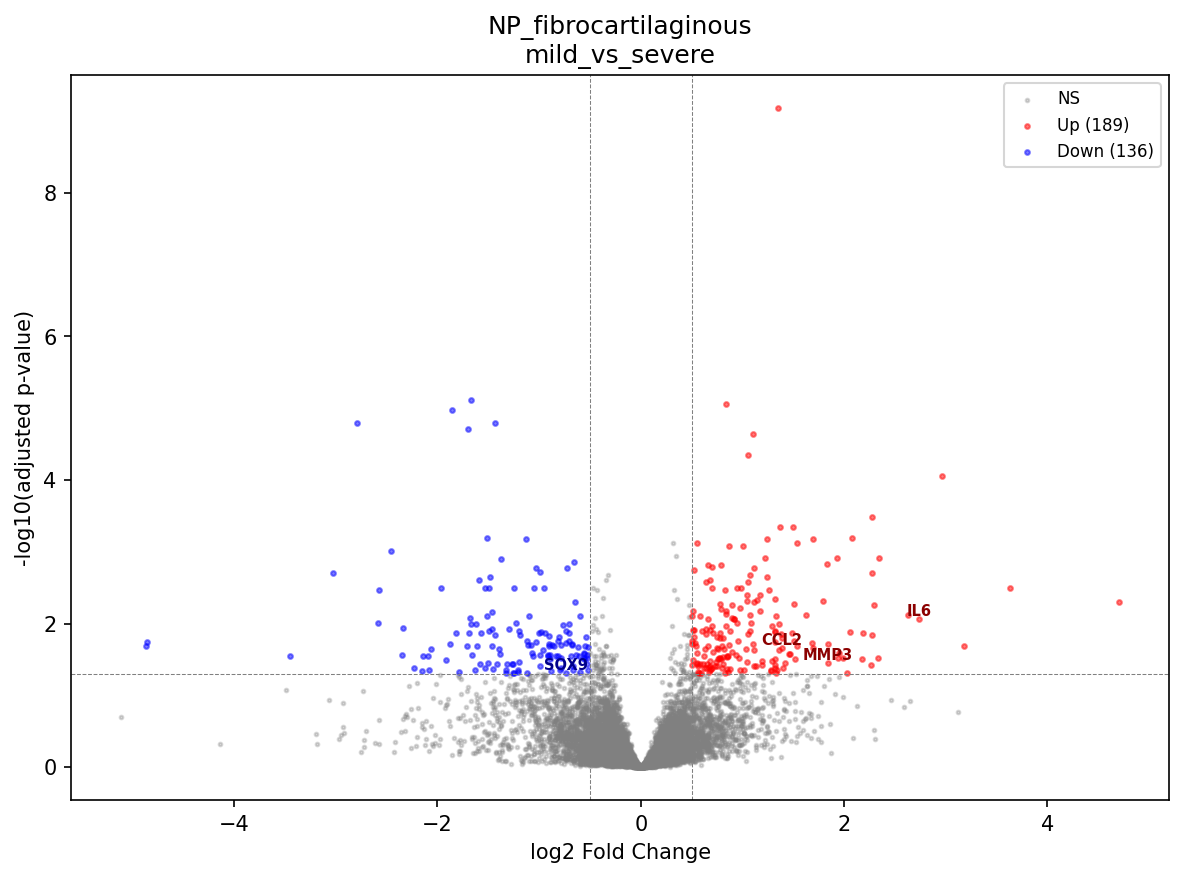

### volcano_NP_fibrochondrocyte_chondroid_mild_vs_severe.png

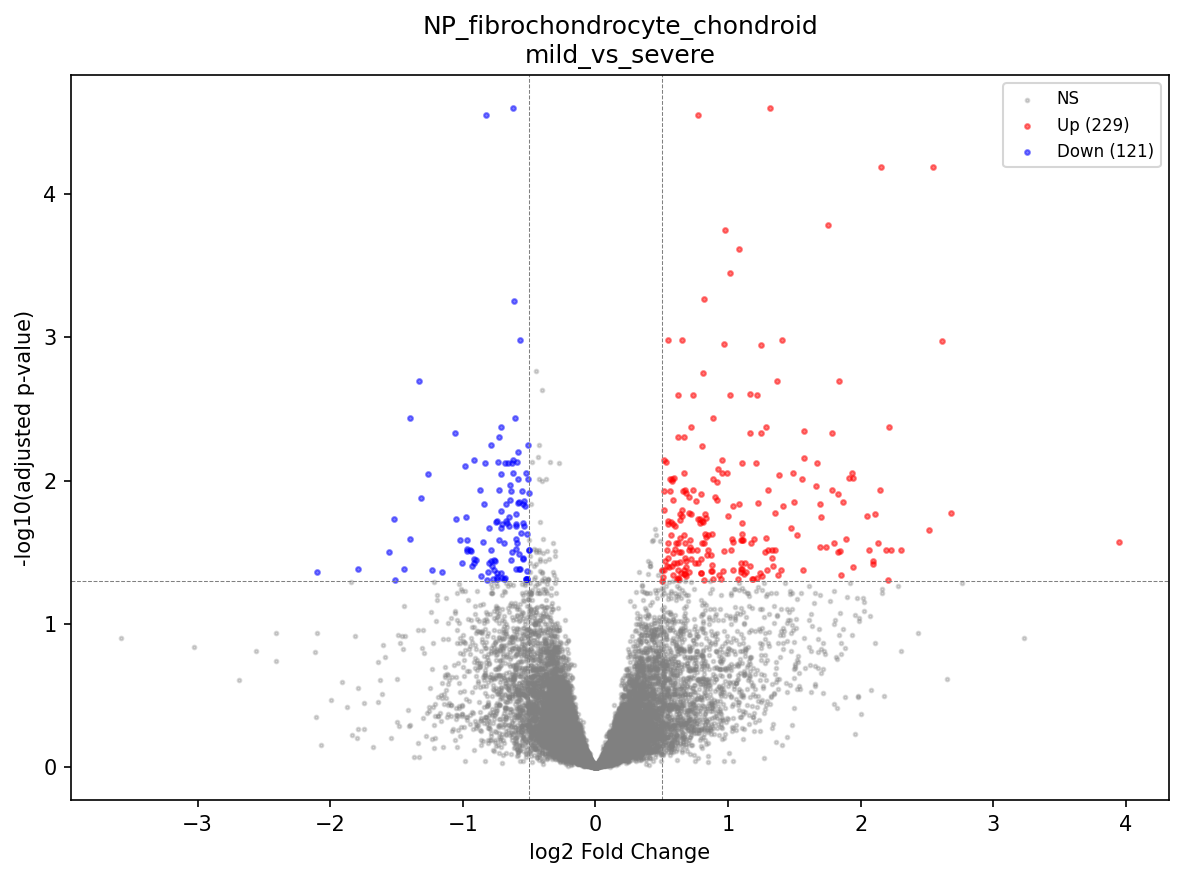

### volcano_NP_mature_chondrocyte_mild_vs_severe.png

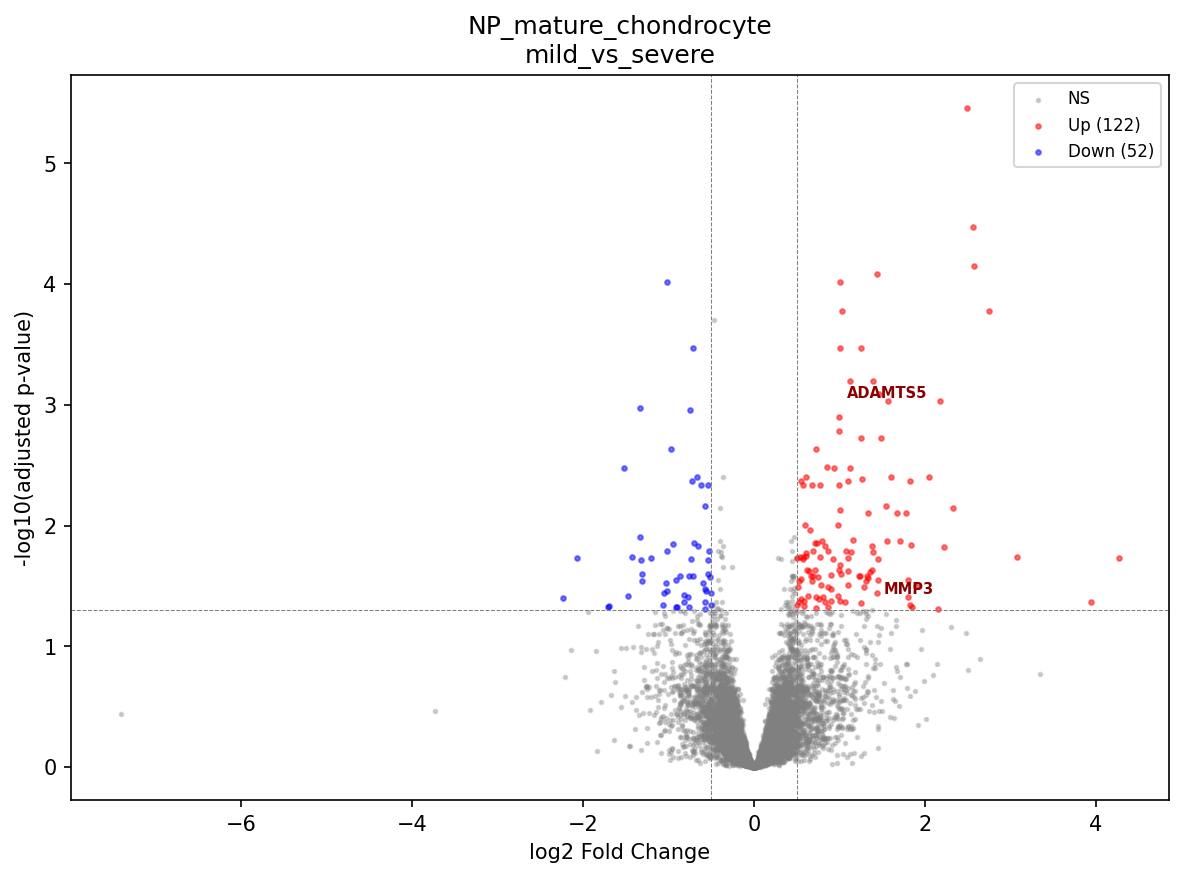

### volcano_NP_fibrocartilaginous_healthy_vs_degenerated_severe.png

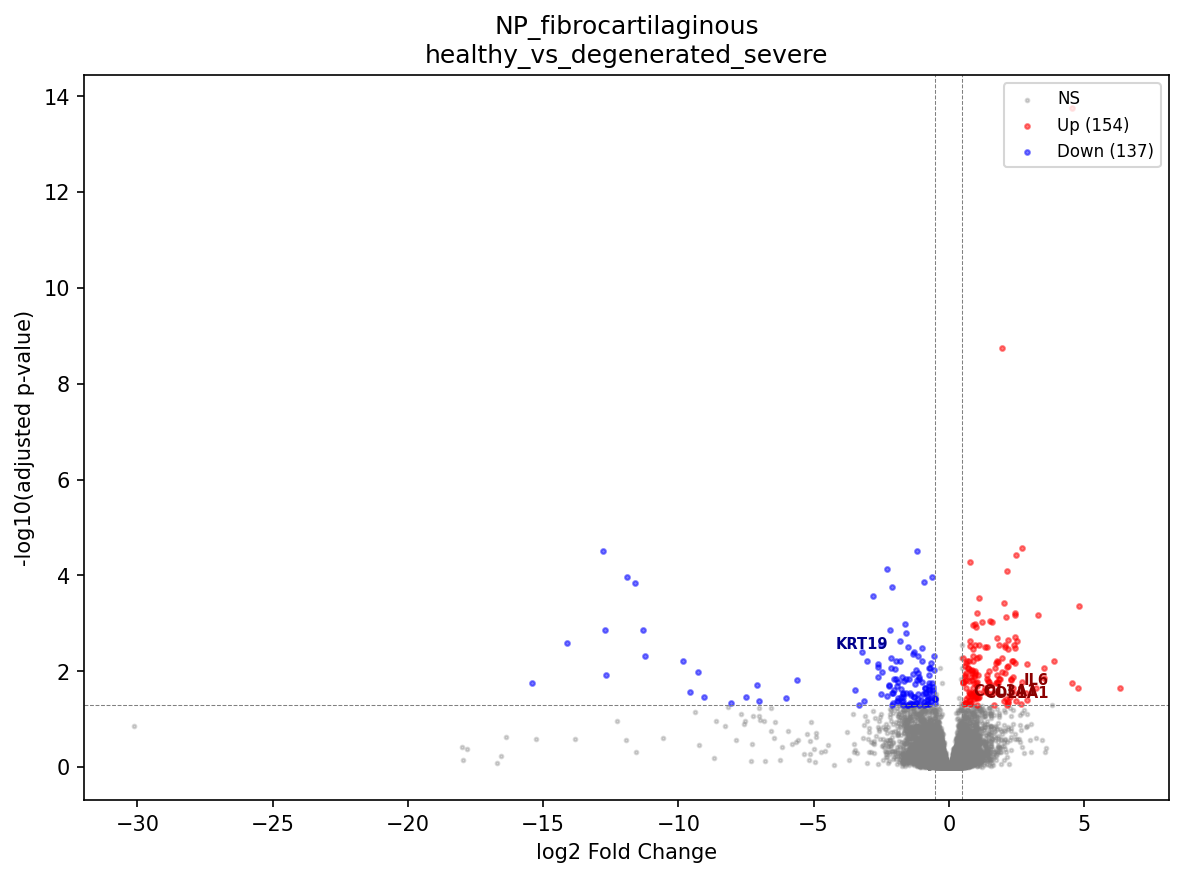

### volcano_AF_outer_healthy_vs_degenerated_mild.png

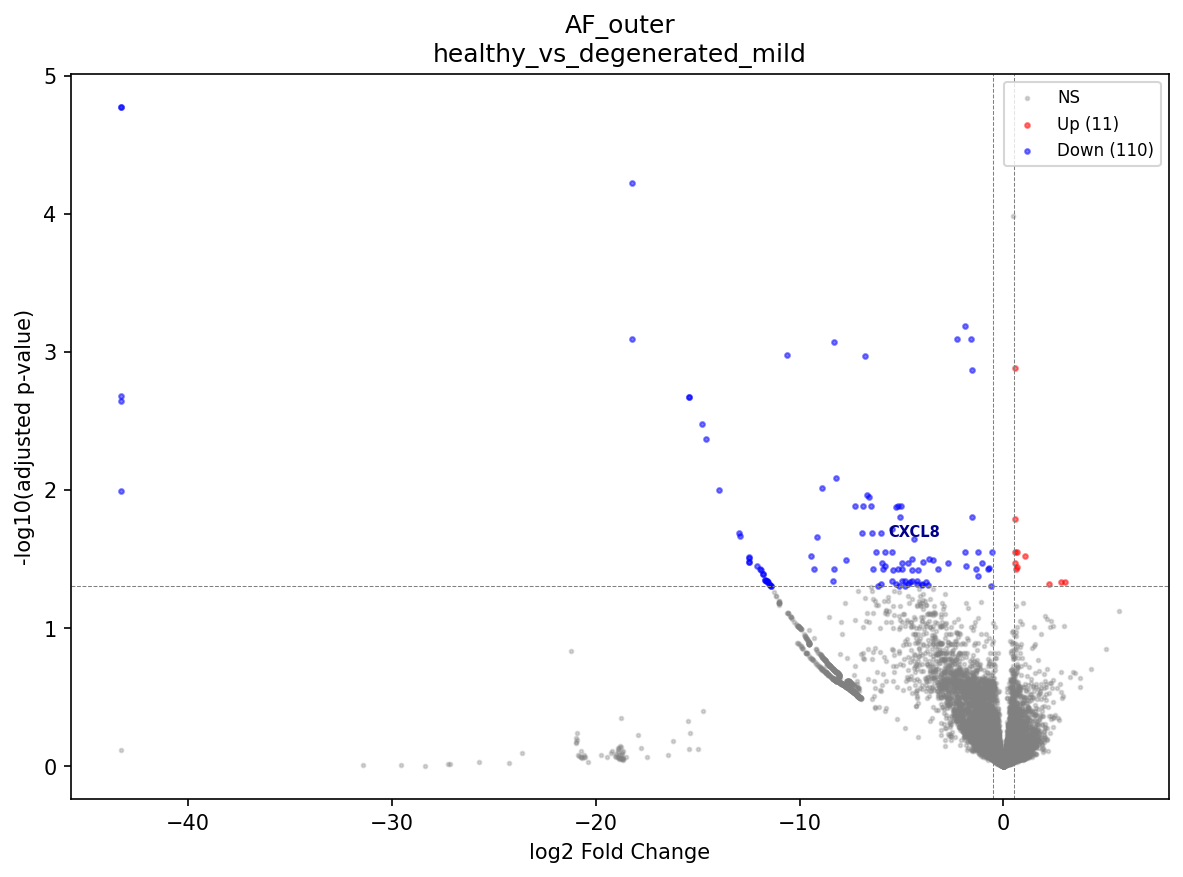

### volcano_Immune_healthy_vs_degenerated_severe.png

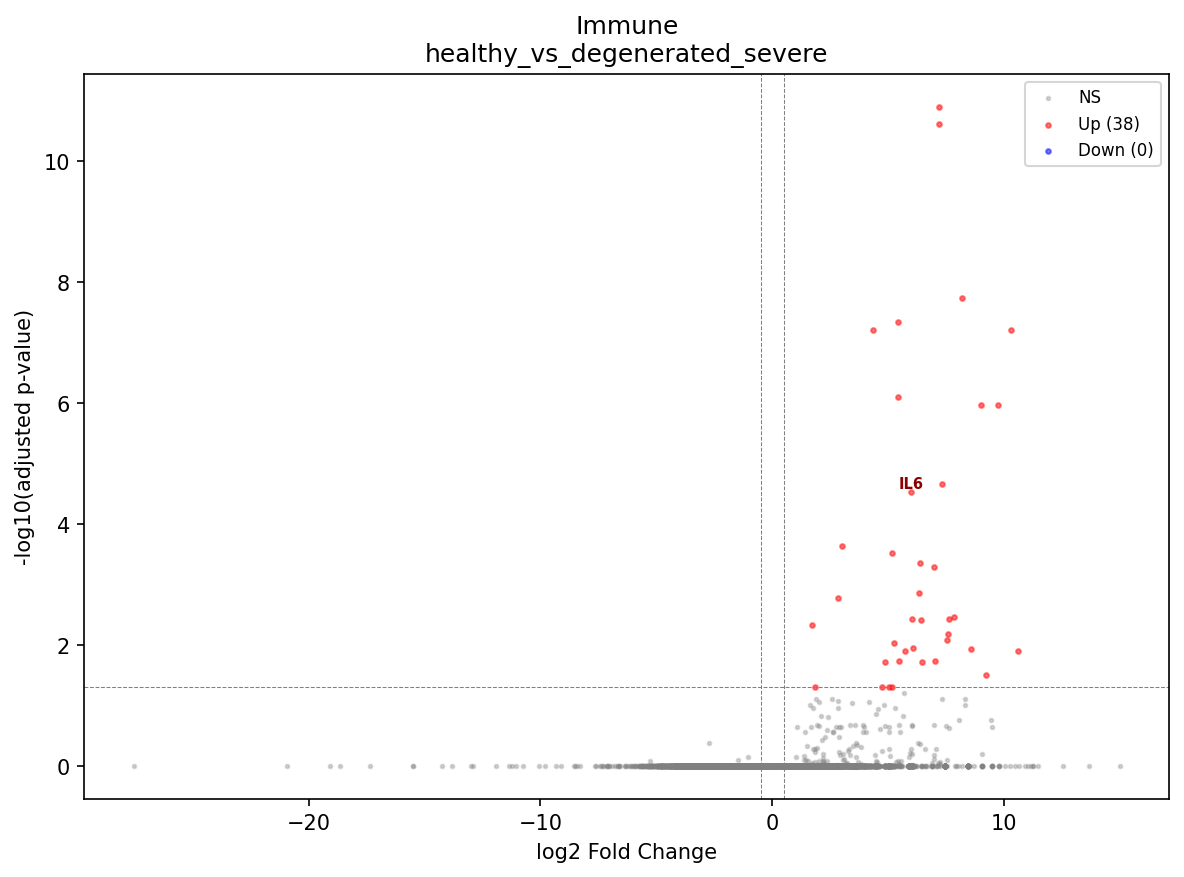

In [13]:
# Top volcano plots: the strongest signals are NP mes mild_vs_severe contrasts
key_volcanos = [
    'volcano_NP_fibrocartilaginous_mild_vs_severe.png',
    'volcano_NP_fibrochondrocyte_chondroid_mild_vs_severe.png',
    'volcano_NP_mature_chondrocyte_mild_vs_severe.png',
    'volcano_NP_fibrocartilaginous_healthy_vs_degenerated_severe.png',
    'volcano_AF_outer_healthy_vs_degenerated_mild.png',
    'volcano_Immune_healthy_vs_degenerated_severe.png',
]
for fname in key_volcanos:
    fpath = TV4_VOLCANO / fname
    if fpath.exists():
        display(Markdown(f'### {fname}'))
        display(Image(filename=str(fpath), width=900))